# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_ind
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [2]:
medical.shape

(1338, 8)

In [3]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__
The distribution of medical charges is right-skewed, with high-cost outliers extending the upper tail. Because of this skewness, the mean may be larger than the typical value and the standard deviation may be inflated by extreme charges. Therefore, while the mean and standard deviation can be calculated, they may not be the most appropriate measures of center and spread for this data.

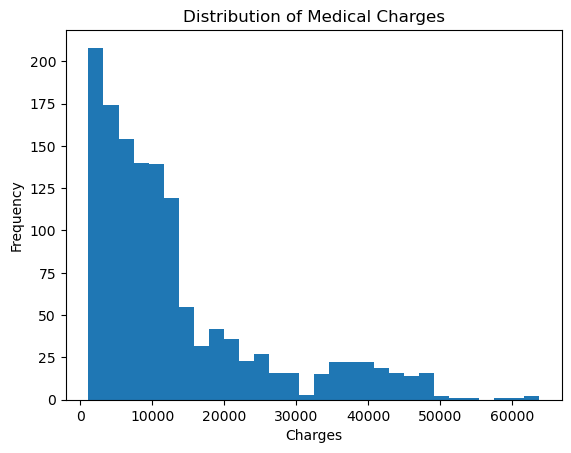

Average charge amount:  13270.42
Standard deviation of charges:  12110.01


In [4]:
# Mean and std calculations
sample_mean = medical['charges'].mean()
sample_std = medical['charges'].std(ddof=1)

# PLot histogram
plt.hist(medical['charges'], bins=30,)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')
plt.show()

# Output
print("Average charge amount: ", round(sample_mean, 2))
print("Standard deviation of charges: ", round(sample_std, 2))

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__
Since the data are assumed to be a random sample, the sample mean can be used to estimate the population mean. Because the sample size is large, the Central Limit Theorem allows us to use statistical inference on the mean even if the data are skewed. Since the population standard deviation is unknown, the appropriate test is a one-sample, left-tailed t-test to determine whether the true mean is below 12,000.

In [5]:
# Sample size
n = len(medical)

# Standard error
standard_error = sample_std / np.sqrt(n)

# t-statistic
t_stat = (sample_mean - 12000) / standard_error

# One-sided (left-tailed) p-value
p_value = t.cdf(t_stat, df=n-1)

# Output
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 3.837351719658534
p-value: 0.9999349141739535


__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__
Based on the analysis, we are 95% confident that the true average charge is at least 12,725. Since this value is well above 12,000, there is no statistical evidence that the average charge has fallen below the concern threshold. Based on the data we have, there is no reason to believe the hospital’s operational model is currently at risk.

In [6]:
# one-sided 95% t critical value
t_crit_one_sided = t.ppf(0.95, df=n-1)

# one-sided lower 95% confidence bound
lower_bound = sample_mean - t_crit_one_sided * standard_error

print("Sample mean:", sample_mean)
print("Standard error:", standard_error)
print("t critical (one-sided 95%):", t_crit_one_sided)
print("One-sided 95% lower bound for mean:", round(lower_bound, 2))

Sample mean: 13270.422265141257
Standard error: 331.06745431568226
t critical (one-sided 95%): 1.6459941145571317
One-sided 95% lower bound for mean: 12725.49


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ 
The null hypothesis states that there is no difference in the average medical charges between insured and uninsured patients.
The alternative hypothesis states that there is a difference in the average medical charges between insured and uninsured patients.
We assume the two populations have equal true variances in order to use the pooled standard deviation in the t-test.

In [7]:
# Split charges into two groups by insuranceclaim (0/1)
insured_charges = medical.loc[medical['insuranceclaim'] == 1, 'charges']
uninsured_charges = medical.loc[medical['insuranceclaim'] == 0, 'charges']

# Sample sizes
num_insured = len(insured_charges)
num_uninsured = len(uninsured_charges)

# Sample means
mean_insured = insured_charges.mean()
mean_uninsured = uninsured_charges.mean()

# Sample standard deviations (ddof=1 for sample std)
std_insured = insured_charges.std(ddof=1)
std_uninsured = uninsured_charges.std(ddof=1)

# Pooled standard deviation (sp)
pooled_std = np.sqrt(((num_uninsured - 1) * std_uninsured**2 + (num_insured - 1) * std_insured**2) / (num_uninsured + num_insured - 2))

# Standard error of the difference
standard_error_difference = pooled_std * np.sqrt(1/num_uninsured + 1/num_insured)

# t-statistic
t_statistic = (mean_uninsured - mean_insured) / standard_error_difference

# Degrees of freedom
degrees_of_freedom = num_uninsured + num_insured - 2

print("Number uninsured:", num_uninsured)
print("Number insured:", num_insured)
print("Mean uninsured:", round(mean_uninsured, 2))
print("Mean insured:", round(mean_insured, 2))
print("Pooled standard deviation:", round(pooled_std, 2))
print("t-statistic:", round(t_statistic, 4))
print("Degrees of freedom:", degrees_of_freedom)

Number uninsured: 555
Number insured: 783
Mean uninsured: 8821.42
Mean insured: 16423.93
Pooled standard deviation: 11520.03
t-statistic: -11.8933
Degrees of freedom: 1336


__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [8]:
# Manual two-sided p-value
p_value_manual = 2 * (t.sf(abs(t_statistic), df=degrees_of_freedom))

print("Manual results:")
print("t-statistic =", round(t_statistic, 4))
print("p-value =", p_value_manual)

# Run the two-sample pooled t-test
scipy_t, scipy_p = ttest_ind(uninsured_charges, insured_charges, equal_var=True)

print("SciPy results:")
print("t-statistic =", round(scipy_t, 4))
print("p-value =", scipy_p)

Manual results:
t-statistic = -11.8933
p-value = 4.4612302316205886e-31
SciPy results:
t-statistic = -11.8933
p-value = 4.461230231620717e-31


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__

SciPy provides built-in functions for performing t-tests, such as ttest_1samp and ttest_ind. However, there is no direct built-in function for performing a z-test on a sample mean. This is likely because z-tests require knowledge of the true population standard deviation. As a result, t-tests are generally used instead.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test